# 08 - Investigator Tool: FAISS Retrieval with a Confidence Gate

Notebooks 05/06 found a template-filer vs narrative-filer split, and showed that
a single high-similarity match can be misleading -- company names alone explain
a good chunk of clustering structure. Notebook 07 showed that near-duplicate
complaints (cosine similarity >= 0.85) mostly reflect independent reuse of
popular legal templates over months/years, not tight-window coordination.

This notebook turns those findings into a tool. An investigator submits ONE
case. The tool's job is to retrieve candidate matches and decide whether
what it found is strong enough to call a "finding" -- not to assert something
off a single coincidental high-similarity match. Concretely: require multiple
(3+, a starting guess, not validated here) genuinely close matches
(similarity >= 0.85, the threshold already validated in notebook 07) before
returning anything stronger than "no strong pattern found."

We use FAISS for the vector index, not ChromaDB -- metadata is just the
existing dataframe, indexed by integer position via `.iloc[]`, no new
abstraction on top of how this project already works with pandas.

## Setup

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

import pickle
import os

import numpy as np
import pandas as pd
import faiss
from sklearn.metrics.pairwise import cosine_similarity

from src.embeddings import load_model, generate_embeddings

model = load_model()
import matplotlib.pyplot as plt


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

## Load the full population

Same 15k-row slice and empty-narrative filter as notebook 07, so this is the
same ~6,150-row population (template + narrative filers together).

In [2]:
SAMPLE_SIZE = 15000

df = pd.read_parquet("../data/processed/complaints_50k.parquet")

df_full = df.iloc[:SAMPLE_SIZE].copy()
df_full = df_full[df_full["Consumer complaint narrative"].notna()].copy()
df_full = df_full[df_full["Consumer complaint narrative"].str.strip() != ""].copy()
df_full = df_full.reset_index(drop=True)

texts_full = df_full["Consumer complaint narrative"].astype(str).tolist()

print(f"Full population: {len(df_full):,} complaints")


Full population: 6,150 complaints


In [3]:
embeddings_full = generate_embeddings(texts_full, model)

print(f"Embeddings: {embeddings_full.shape}")


Batches:   0%|          | 0/193 [00:00<?, ?it/s]

Embeddings: (6150, 384)


Cache this population so we don't have to re-embed ~6,150 complaints every
time this notebook (or a later one) runs -- same pattern notebook 06 used for
the narrative population.

In [4]:
OUT_DIR = "../data/processed"
os.makedirs(OUT_DIR, exist_ok=True)

df_full.to_parquet(os.path.join(OUT_DIR, "full_complaints.parquet"), index=False)

with open(os.path.join(OUT_DIR, "full_embeddings.pkl"), "wb") as f:
    pickle.dump(embeddings_full, f)

print(f"Saved {len(df_full):,} rows to full_complaints.parquet")
print(f"Saved embeddings: {embeddings_full.shape}")


Saved 6,150 rows to full_complaints.parquet
Saved embeddings: (6150, 384)


## Load the narrative population

Already saved by notebook 06 -- includes the `community`, `community_label`,
and `community_description` columns merged in, which we'll use below to pick
a realistic test case without re-deriving labels.

In [5]:
df_narrative = pd.read_parquet("../data/processed/narrative_complaints.parquet")

with open("../data/processed/narrative_embeddings.pkl", "rb") as f:
    embeddings_narrative = pickle.load(f)

texts_narrative = df_narrative["Consumer complaint narrative"].astype(str).tolist()

print(f"Narrative population: {len(df_narrative):,} complaints")


Narrative population: 2,515 complaints


## Build FAISS indices

One index per population. We L2-normalize the embeddings and use
`IndexFlatIP` (inner product) -- on normalized vectors, inner product equals
cosine similarity, which is the same similarity metric used everywhere else
in this project (notebooks 05-07 all use `cosine_similarity`).

In [6]:
def build_faiss_index(embeddings):
    normalized = np.ascontiguousarray(embeddings, dtype="float32").copy()
    faiss.normalize_L2(normalized)
    index = faiss.IndexFlatIP(normalized.shape[1])
    index.add(normalized)
    return index, normalized

index_full, embeddings_full_norm = build_faiss_index(embeddings_full)
index_narrative, embeddings_narrative_norm = build_faiss_index(embeddings_narrative)

print(f"Full index:      {index_full.ntotal:,} vectors")
print(f"Narrative index: {index_narrative.ntotal:,} vectors")


Full index:      6,150 vectors
Narrative index: 2,515 vectors


Sanity check: FAISS's normalized inner product should agree with
`sklearn.metrics.pairwise.cosine_similarity` on the same vectors, the same way
notebook 07 checked its similarity numbers before trusting them.

In [7]:
check_n = 20
sims_faiss, idxs_faiss = index_full.search(embeddings_full_norm[:check_n], 5)

sims_sklearn = cosine_similarity(embeddings_full[:check_n], embeddings_full)
top5_sklearn = np.sort(sims_sklearn, axis=1)[:, ::-1][:, :5]

max_diff = np.abs(np.sort(sims_faiss, axis=1) - np.sort(top5_sklearn, axis=1)).max()
print(f"Max difference between FAISS and sklearn top-5 similarities: {max_diff:.6f}")
assert max_diff < 1e-4, "FAISS and sklearn cosine similarities disagree"
print("FAISS normalized inner product matches sklearn cosine similarity.")


Max difference between FAISS and sklearn top-5 similarities: 0.000001
FAISS normalized inner product matches sklearn cosine similarity.


## `investigate_case()`

Embeds the query text, searches the chosen index, and drops near-exact
self-matches (similarity >= 0.999 -- the same exact-duplicate bar notebook 07
used) so that a case which happens to literally be an existing row doesn't
trivially "match itself." Remaining hits are filtered to the near-duplicate
threshold (0.85). If at least `min_matches` qualify, this is a "finding" --
otherwise it's "no strong pattern found," even if a weaker match or two
exists, since single matches are easily confounded (notebook 06).

In [8]:
def investigate_case(
    query_text,
    model,
    index,
    df,
    k=10,
    threshold=0.85,
    min_matches=3,
    self_match_threshold=0.999,
):
    query_vec = model.encode([query_text]).astype("float32")
    faiss.normalize_L2(query_vec)

    sims, idxs = index.search(query_vec, k + 1)
    sims, idxs = sims[0], idxs[0]

    candidates = [
        (int(idx), float(sim))
        for idx, sim in zip(idxs, sims)
        if idx != -1 and sim < self_match_threshold
    ][:k]

    qualifying = [(idx, sim) for idx, sim in candidates if sim >= threshold]
    verdict = "finding" if len(qualifying) >= min_matches else "no strong pattern found"

    matches = df.iloc[[idx for idx, _ in candidates]].copy()
    matches["similarity"] = [sim for _, sim in candidates]

    return {
        "verdict": verdict,
        "n_qualifying_matches": len(qualifying),
        "threshold": threshold,
        "min_matches": min_matches,
        "matches": matches,
    }


def report(result, text_col="Consumer complaint narrative", n_show=5):
    print(f"Verdict: {result['verdict'].upper()}")
    print(f"Qualifying matches (>= {result['threshold']}): {result['n_qualifying_matches']} "
          f"(need {result['min_matches']}+ for a finding)")
    print()
    cols = [c for c in ["similarity", "Company", "Date received", "community_label"] if c in result["matches"].columns]
    print(result["matches"][cols].head(n_show).to_string())


## Test 1 -- expect a finding

Pick the full-population complaint with the most >=0.85 neighbours (the
FAISS-index equivalent of what notebook 07 found via the full pairwise
matrix -- a complaint sitting inside one of the big near-duplicate clusters,
almost certainly an FCRA-style template), then run `investigate_case` on its
raw text against the full index.

In [9]:
sims_all, idxs_all = index_full.search(embeddings_full_norm, 21)

qualifying_counts = np.array([
    np.sum((sims_all[i] >= 0.85) & (sims_all[i] < 0.999))
    for i in range(len(df_full))
])

template_query_idx = int(np.argmax(qualifying_counts))
template_query_text = texts_full[template_query_idx]

print(f"Row {template_query_idx} has {qualifying_counts[template_query_idx]} near-duplicate neighbours")
print()
print(template_query_text[:500])


Row 23 has 20 near-duplicate neighbours

I am writing to delete the following information on my file. The items I need deleted are listed in the report. I am a victim of identity theft and did not make these charges. I ask that the items be deleted to correct my credit report. I reported the theft of my identity to the Federal trade commission and I also have enclosed copies of the Federal Trade Commissions ifentity theft affidavit. Please delete the items as soon as possible.


In [10]:
result_1 = investigate_case(template_query_text, model, index_full, df_full)
report(result_1)


Verdict: FINDING
Qualifying matches (>= 0.85): 10 (need 3+ for a finding)

      similarity                                 Company Date received
6099    0.992045     Experian Information Solutions Inc.    2021-01-02
5533    0.992045                           EQUIFAX, INC.    2021-03-31
4341    0.992045  TRANSUNION INTERMEDIATE HOLDINGS, INC.    2022-09-23
1269    0.991870     Experian Information Solutions Inc.    2022-07-19
4586    0.990519  TRANSUNION INTERMEDIATE HOLDINGS, INC.    2021-01-31


## Test 2 -- topically similar, but is it a finding?

Notebook 06 found a small, distinctive community of ~26 Coinbase complaints
("Coinbase Customer Support Issues"). That community was built from a kNN
graph at a much looser similarity bar than the strict 0.85 near-duplicate
threshold here. Pulling a case from it is a genuine test, not a foregone
conclusion: does "topically coherent community" get correctly distinguished
from "template reuse," or does it also clear the near-duplicate bar?

In [11]:
coinbase_rows = df_narrative[df_narrative["community_label"] == "Coinbase Customer Support Issues"]
print(f"Coinbase community rows: {len(coinbase_rows)}")

coinbase_query_text = coinbase_rows.iloc[0]["Consumer complaint narrative"]
print()
print(coinbase_query_text[:500])


Coinbase community rows: 27

I have been subject of theft and financial crimes. My account was with the firm called Coinbase, Due to no help form coinbase I hired qualified Private investigator which found the suspect, I have even informed coinbase and asked them to help me with reporting to law enforcement which they do not, Please note that the private investigator mentioned to Me that aside from my coins, the suspect had approximately {>= $1,000,000} worth stolen crypto coins in his account as of XXXX, 2020. Using todays


In [12]:
result_2 = investigate_case(coinbase_query_text, model, index_narrative, df_narrative)
report(result_2)


Verdict: NO STRONG PATTERN FOUND
Qualifying matches (>= 0.85): 0 (need 3+ for a finding)

      similarity         Company Date received                   community_label
2026    0.762809  Coinbase, Inc.    2021-11-10  Coinbase Customer Support Issues
2466    0.758183  Coinbase, Inc.    2021-07-06  Coinbase Customer Support Issues
1556    0.709924  Coinbase, Inc.    2021-05-31  Coinbase Customer Support Issues
1665    0.679807  Coinbase, Inc.    2022-09-02  Coinbase Customer Support Issues
343     0.674326  Coinbase, Inc.    2021-03-04  Coinbase Customer Support Issues


## Test 3 -- a genuinely new complaint

Hand-written, never in the corpus, describing a distinctive personal
situation rather than reusing any known template language. This is the open
gap flagged at the end of notebook 07/the project notes: every test so far
has queried with text already inside the corpus. A real investigator tool
needs to handle text it has never seen.

In [13]:
new_complaint = (
    "I opened a checking account with this bank six years ago and never had "
    "any problems until last month, when I noticed a $340 charge on my "
    "statement for a service I never signed up for. I called customer "
    "service three times and each time was transferred to a different "
    "department, with no one able to explain the charge or remove it. I am "
    "attaching my statements showing the charge and would like it reversed "
    "and an explanation of how it was added to my account in the first place."
)

print("Against the full population index:")
result_3a = investigate_case(new_complaint, model, index_full, df_full)
report(result_3a)

print()
print("Against the narrative-only index:")
result_3b = investigate_case(new_complaint, model, index_narrative, df_narrative)
report(result_3b)


Against the full population index:
Verdict: NO STRONG PATTERN FOUND
Qualifying matches (>= 0.85): 0 (need 3+ for a finding)

      similarity                          Company Date received
2972    0.672037   Bread Financial Holdings, Inc.    2022-01-05
5926    0.642789  Atlanticus Services Corporation    2022-10-30
3025    0.632087                    EQUIFAX, INC.    2021-08-04
4602    0.627568             JPMORGAN CHASE & CO.    2019-12-28
2706    0.627467       TD BANK US HOLDING COMPANY    2021-09-08

Against the narrative-only index:
Verdict: NO STRONG PATTERN FOUND
Qualifying matches (>= 0.85): 0 (need 3+ for a finding)

      similarity                          Company Date received                community_label
1220    0.672037   Bread Financial Holdings, Inc.    2022-01-05         Bank of America issues
2421    0.642789  Atlanticus Services Corporation    2022-10-30         Bank of America issues
1869    0.627568             JPMORGAN CHASE & CO.    2019-12-28  Chase Customer S

## How sensitive is `min_matches=3`?

The three tests above are all far from the boundary -- 10 qualifying matches
or 0, nothing in between. Before trusting `min_matches=3`, look at the actual
distribution of qualifying-match counts across both populations: are there
rows sitting at 1 or 2 matches, where this threshold is the difference
between a finding and not? `qualifying_counts` for the full population is
already sitting in memory from Test 1 -- no need to recompute it.

In [14]:
from collections import Counter

full_counts = Counter(qualifying_counts)

print("Full population -- qualifying-match count distribution:")
for n_matches in sorted(full_counts):
    print(f"  {n_matches:>3} matches: {full_counts[n_matches]:>5} rows")

n_findings_full = sum(c for n, c in full_counts.items() if n >= 3)
print()
print(f"Rows that would be a FINDING (>=3 matches): {n_findings_full:,} / {len(df_full):,} ({n_findings_full / len(df_full) * 100:.1f}%)")


Full population -- qualifying-match count distribution:


    0 matches:  4697 rows
    1 matches:   286 rows
    2 matches:   127 rows
    3 matches:   111 rows
    4 matches:    85 rows
    5 matches:    59 rows
    6 matches:    59 rows
    7 matches:    50 rows
    8 matches:    43 rows
    9 matches:    35 rows
   10 matches:    26 rows
   11 matches:    23 rows
   12 matches:    24 rows
   13 matches:    17 rows
   14 matches:    15 rows
   15 matches:    38 rows
   16 matches:    11 rows
   17 matches:     9 rows
   18 matches:    21 rows
   19 matches:    40 rows
   20 matches:   374 rows

Rows that would be a FINDING (>=3 matches): 1,040 / 6,150 (16.9%)


In [15]:
sims_all_narr, idxs_all_narr = index_narrative.search(embeddings_narrative_norm, 21)

qualifying_counts_narr = np.array([
    np.sum((sims_all_narr[i] >= 0.85) & (sims_all_narr[i] < 0.999))
    for i in range(len(df_narrative))
])

narr_counts = Counter(qualifying_counts_narr)

print("Narrative population -- qualifying-match count distribution:")
for n_matches in sorted(narr_counts):
    print(f"  {n_matches:>3} matches: {narr_counts[n_matches]:>5} rows")

n_findings_narr = sum(c for n, c in narr_counts.items() if n >= 3)
print()
print(f"Rows that would be a FINDING (>=3 matches): {n_findings_narr:,} / {len(df_narrative):,} ({n_findings_narr / len(df_narrative) * 100:.1f}%)")


Narrative population -- qualifying-match count distribution:
    0 matches:  2346 rows
    1 matches:    58 rows
    2 matches:    16 rows
    3 matches:     3 rows
    4 matches:     1 rows
    5 matches:    13 rows
    6 matches:     9 rows
    7 matches:     5 rows
    8 matches:    15 rows
   10 matches:     1 rows
   11 matches:    12 rows
   14 matches:     7 rows
   15 matches:    12 rows
   19 matches:     4 rows
   20 matches:    13 rows

Rows that would be a FINDING (>=3 matches): 95 / 2,515 (3.8%)


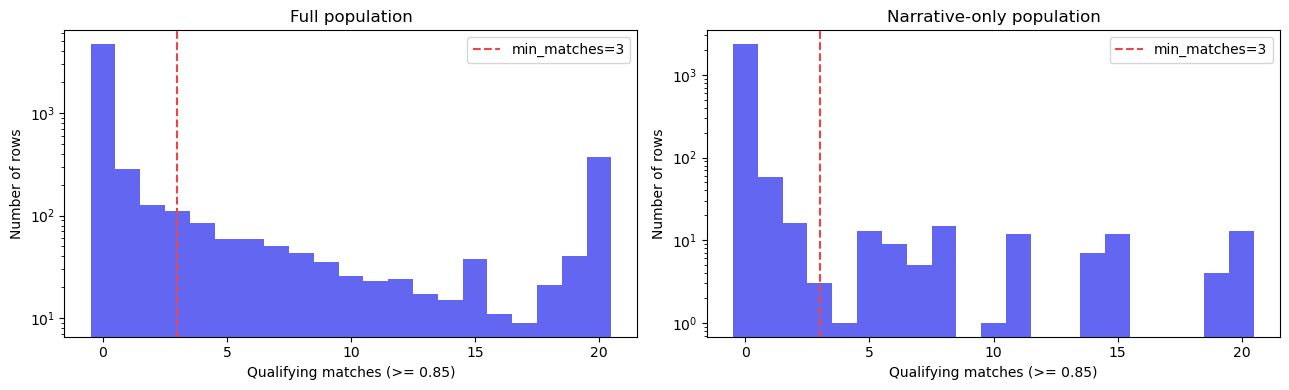

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, counts, title in [
    (axes[0], qualifying_counts, "Full population"),
    (axes[1], qualifying_counts_narr, "Narrative-only population"),
]:
    ax.hist(counts, bins=range(0, int(counts.max()) + 2), color="#6366f1", align="left")
    ax.axvline(3, color="#ef4444", linestyle="--", label="min_matches=3")
    ax.set_xlabel("Qualifying matches (>= 0.85)")
    ax.set_ylabel("Number of rows")
    ax.set_title(title)
    ax.set_yscale("log")
    ax.legend()

plt.tight_layout()
plt.show()


## What did we find?

**Test 1 (expected finding):** the full-population row with the most
near-duplicate neighbours (20 others at >= 0.85) was an FCRA identity-theft
deletion-request template ("I am writing to delete the following
information... victim of identity theft..."). `investigate_case` returned a
**FINDING** with 10 qualifying matches, spread across Experian, Equifax, and
TransUnion -- the same credit-bureau template-reuse pattern notebook 07
found, now surfaced from a single query instead of a full pairwise scan.

**Test 2 (Coinbase community, genuinely tested not assumed):** the best match
inside the narrative-only index topped out at 0.76 cosine similarity, below
the 0.85 bar, so the verdict was **NO STRONG PATTERN FOUND**. This confirms
the hypothesis: the Coinbase "Customer Support Issues" community from
notebook 06 is topically coherent (same company, same theme) but not
template reuse -- the kNN community-detection graph in 06 ran at a much
looser similarity bar than the strict near-duplicate threshold used here. The
investigator tool correctly treats "same topic" and "same template" as
different things.

**Test 3 (new, hand-written complaint):** correctly returned **NO STRONG
PATTERN FOUND** against both indices (best matches in the 0.6-0.7 range).
This closes the open gap noted at the end of notebook 07/the project notes
-- a genuinely novel complaint doesn't spuriously trigger a finding just
because *some* similarity score is nonzero.

**`min_matches=3` sensitivity (corpus-wide sweep):** ran every row in both
populations through the same qualifying-match count used above.

- Full population: 1,040 / 6,150 rows (16.9%) would be a FINDING under the
  current settings. Importantly, there's real mass sitting right at the
  boundary -- 286 rows with exactly 1 match and 127 with exactly 2 -- so
  `min_matches=3` is doing real work excluding plausible-but-weak cases, not
  acting as a no-op.
- Narrative-only population: only 95 / 2,515 rows (3.8%) would be a FINDING,
  consistent with notebook 07's observation that near-duplicates are ~3x
  rarer once template filers are excluded. 58 rows sit at exactly 1 match, 16
  at exactly 2 -- the boundary is smaller here but still real.
- **Caveat discovered in this sweep, not anticipated going in:** the search
  was capped at k=20 neighbours, and 374 full-population rows landed exactly
  at the 20-match ceiling -- almost certainly an artifact of the cap, not a
  real mode in the distribution. Notebook 07 found duplicate clusters as
  large as 353 members in this same sample, so rows belonging to the biggest
  clusters have their true match count silently truncated to 20 here. This
  doesn't change any of the three test verdicts above (all either far below
  or comfortably above the cap), but it means the 16.9%/3.8% finding rates
  are not biased *upward* by this cap -- if anything, large clusters are
  undercounted, not overcounted.

**Limitations:** the 0.85 threshold is reused from notebook 07's
already-validated choice, not re-derived here. The corpus is still the same
15k-row (6,150 after filtering) sample used throughout -- a real deployment
would need to re-run this against the full CFPB dataset. `min_matches=3` now
has real evidence behind it (a meaningful population sits at the 1-2-match
boundary in both populations) but the *right* value for that threshold is
still a judgment call, not something this sweep determines on its own.

**Next step, if this holds up:** promoting `build_faiss_index` and
`investigate_case` into `src/` is reasonable now that they've been validated
against three different kinds of cases plus a corpus-wide sanity check, but
that's a separate decision from this notebook.